## 1. Import Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load Dataset

In [5]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes.value_counts())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
float64    30
int64       1
Name: count, dtype: int64


## 3. Basic Data Inspection

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 4. Target Distribution



In [10]:
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_percent)

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


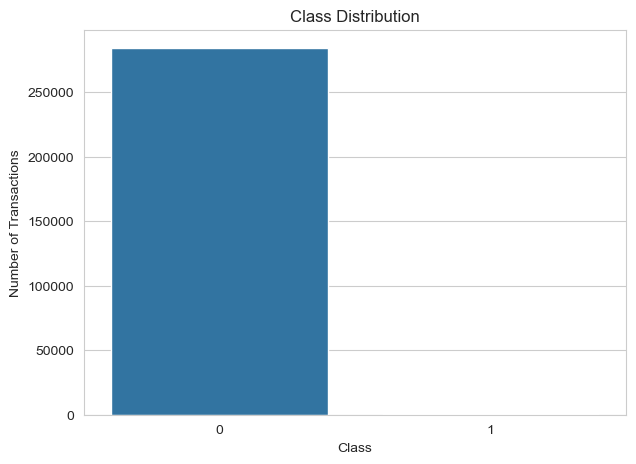

In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

## 5. Transaction Analysis

In [12]:
print("Average transaction amount:")
print(df.groupby("Class")["Amount"].mean())

print("\nAverage transaction time:")
print(df.groupby("Class")["Time"].mean())

Average transaction amount:
Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

Average transaction time:
Class
0    94838.202258
1    80746.806911
Name: Time, dtype: float64


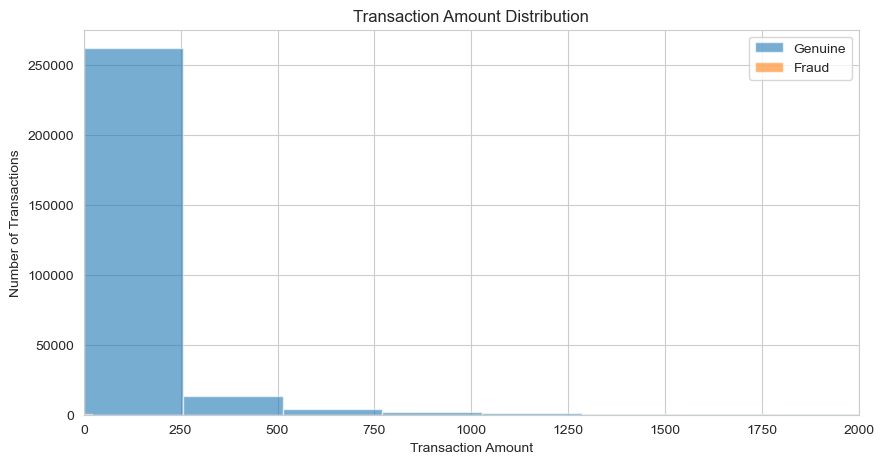

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["Class"] == 0, "Amount"], bins=100, alpha=0.6, label="Genuine")
plt.hist(df.loc[df["Class"] == 1, "Amount"], bins=100, alpha=0.6, label="Fraud")
plt.xlim(0, 2000)
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

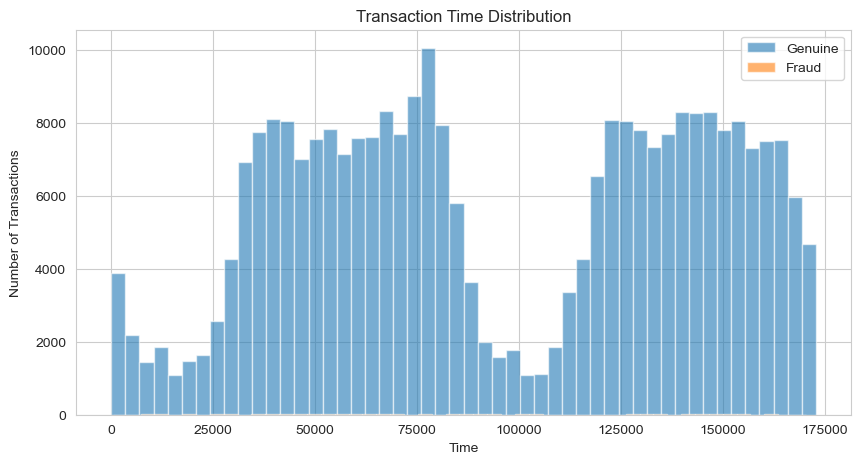

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df.loc[df["Class"] == 0, "Time"], bins=50, alpha=0.6, label="Genuine")
plt.hist(df.loc[df["Class"] == 1, "Time"], bins=50, alpha=0.6, label="Fraud")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")
plt.title("Transaction Time Distribution")
plt.legend()
plt.show()

## 6. Correlation Analysis



## 8. Validation and Test Split



In [15]:
X = df.drop(columns="Class").copy()
y = df["Class"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

correlation_threshold = 0.90

feature_corr = X_train_full.corr().abs()
upper = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .rename("Correlation")
    .reset_index()
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

print("Features removed using Pearson correlation threshold 0.90:")
print(to_drop)
print("Number of removed features:", len(to_drop))

X_train_full = X_train_full.drop(columns=to_drop)
X_train = X_train.drop(columns=to_drop)
X_val = X_val.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print("Final feature count:", X_train.shape[1])

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())


Features removed using Pearson correlation threshold 0.90:
[]
Number of removed features: 0
Final feature count: 30
Training: (182276, 30)
Validation: (45569, 30)
Test: (56962, 30)

Training class distribution:
Class
0    181961
1       315
Name: count, dtype: int64

Validation class distribution:
Class
0    45490
1       79
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 9. Standardization



In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 10. Compare Imbalance-Handling Strategies



In [17]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print("Original:")
print(y_train.value_counts())

print("\nSMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nRandom Undersampling:")
print(pd.Series(y_train_rus).value_counts())

  File "C:\Users\verma\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\verma\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\verma\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\verma\anaconda3\Lib\subprocess.

Original:
Class
0    181961
1       315
Name: count, dtype: int64

SMOTE:
Class
0    181961
1    181961
Name: count, dtype: int64

Random Undersampling:
Class
0    315
1    315
Name: count, dtype: int64


## 11. Evaluation Function

In [18]:
def evaluate_model(model, X_eval, y_eval, model_name, threshold=0.5):
    probability = model.predict_proba(X_eval)[:, 1]
    prediction = (probability >= threshold).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, prediction),
        "Precision": precision_score(y_eval, prediction, zero_division=0),
        "Recall": recall_score(y_eval, prediction, zero_division=0),
        "F1": f1_score(y_eval, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, probability),
        "PR-AUC": average_precision_score(y_eval, probability)
    }

## 12. Baseline Models



In [19]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)
nb = GaussianNB()

baseline_models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gaussian Naive Bayes": nb
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_smote, y_train_smote)
    result = evaluate_model(model, X_val_scaled, y_val, name)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.sort_values("PR-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Random Forest,0.999429,0.884058,0.772152,0.824324,0.969298,0.808116
0,Logistic Regression,0.973359,0.054203,0.873418,0.102071,0.968670,0.681399
1,Decision Tree,0.996950,0.325581,0.708861,0.446215,0.853155,0.231297
3,Gaussian Naive Bayes,0.975619,0.057461,0.848101,0.107631,0.947855,0.085085


## Research Paper Methodology Extension



In [20]:
svm = SVC(
    probability=True,
    random_state=RANDOM_STATE
)

svm.fit(X_train_rus, y_train_rus)

svm_result = evaluate_model(
    svm,
    X_val_scaled,
    y_val,
    "SVM - Random Undersampling"
)

pd.DataFrame([svm_result])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,SVM - Random Undersampling,0.967873,0.045305,0.873418,0.086142,0.972083,0.690826


In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## Hyperparameter Tuning of Classical Models



In [22]:
lr_param_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"]
}

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}

knn_param_grid = {
    "n_neighbors": [5, 9],
    "weights": ["uniform", "distance"]
}

svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale"]
}

lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    lr_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

knn_grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

svm_grid_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

lr_grid_search.fit(X_train_smote, y_train_smote)
dt_grid_search.fit(X_train_smote, y_train_smote)
rf_grid_search.fit(X_train_smote, y_train_smote)
knn_grid_search.fit(X_train_rus, y_train_rus)
svm_grid_search.fit(X_train_rus, y_train_rus)

classical_tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Best Parameters": [
        lr_grid_search.best_params_,
        dt_grid_search.best_params_,
        rf_grid_search.best_params_,
        knn_grid_search.best_params_,
        svm_grid_search.best_params_
    ],
    "Best CV PR-AUC": [
        lr_grid_search.best_score_,
        dt_grid_search.best_score_,
        rf_grid_search.best_score_,
        knn_grid_search.best_score_,
        svm_grid_search.best_score_
    ]
})

classical_tuning_results

,Model,Best Parameters,Best CV PR-AUC
0,Logistic Regression,"{'C': 10, 'penalty': 'l2'}",0.994003
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.998135
2,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.999994
3,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.977354
4,SVM,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.986150


## 10-Fold Stratified Validation



In [31]:
cv_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", tuned_xgb)
])

In [32]:
cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores_10 = cross_validate(
    cv_pipeline,
    X_train_full,
    y_train_full,
    cv=cv_10,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

cv_summary_10 = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Mean": [
        cv_scores_10["test_precision"].mean(),
        cv_scores_10["test_recall"].mean(),
        cv_scores_10["test_f1"].mean(),
        cv_scores_10["test_roc_auc"].mean(),
        cv_scores_10["test_pr_auc"].mean()
    ],
    "Std": [
        cv_scores_10["test_precision"].std(),
        cv_scores_10["test_recall"].std(),
        cv_scores_10["test_f1"].std(),
        cv_scores_10["test_roc_auc"].std(),
        cv_scores_10["test_pr_auc"].std()
    ]
})

cv_summary_10

,Metric,Mean,Std
0,Precision,0.836157,0.058578
1,Recall,0.835321,0.041676
2,F1,0.833521,0.027470
3,ROC-AUC,0.981644,0.013609
4,PR-AUC,0.852190,0.028393


In [33]:
knn = KNeighborsClassifier(n_neighbors=9, weights="distance", n_jobs=-1)
knn.fit(X_train_rus, y_train_rus)

knn_result = evaluate_model(
    knn,
    X_val_scaled,
    y_val,
    "KNN - Random Undersampling"
)

pd.DataFrame([knn_result])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,KNN - Random Undersampling,0.981654,0.077095,0.873418,0.141684,0.965037,0.523547


## 13. XGBoost Baseline

In [25]:
xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_baseline.fit(X_train_smote, y_train_smote)

xgb_baseline_result = evaluate_model(
    xgb_baseline,
    X_val_scaled,
    y_val,
    "XGBoost"
)

pd.DataFrame([xgb_baseline_result])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.998574,0.5625,0.797468,0.659686,0.966967,0.794665


## 14. Sampling Strategy Comparison with XGBoost



In [26]:
sampling_models = {
    "Original": (X_train_scaled, y_train),
    "SMOTE": (X_train_smote, y_train_smote),
    "Random Undersampling": (X_train_rus, y_train_rus)
}

sampling_results = []

for sampling_name, (X_fit, y_fit) in sampling_models.items():
    model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.10,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_fit, y_fit)
    result = evaluate_model(
        model,
        X_val_scaled,
        y_val,
        f"XGBoost - {sampling_name}"
    )
    sampling_results.append(result)

sampling_results_df = pd.DataFrame(sampling_results)
sampling_results_df.sort_values("PR-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost - Original,0.999517,0.938462,0.772152,0.847222,0.978322,0.843930
1,XGBoost - SMOTE,0.998574,0.562500,0.797468,0.659686,0.966967,0.794665
2,XGBoost - Random Undersampling,0.964581,0.042338,0.898734,0.080866,0.974201,0.680195


## 15. Hyperparameter Tuning with GridSearchCV



In [27]:
xgb_for_grid = XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [5, 8, 11],
    "learning_rate": [0.05, 0.10],
    "min_child_weight": [3, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=xgb_for_grid,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest CV PR-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 11, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}

Best CV PR-AUC: 0.9999888762408251


In [28]:
tuned_xgb = grid_search.best_estimator_

tuned_xgb_val_result = evaluate_model(
    tuned_xgb,
    X_val_scaled,
    y_val,
    "Tuned XGBoost"
)

pd.DataFrame([tuned_xgb_val_result])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.999342,0.795181,0.835443,0.814815,0.960142,0.837184


## 16. Cross-Validation of the Tuned Model



In [29]:
cv_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", XGBClassifier(
        **grid_search.best_params_,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

cv_scores = cross_validate(
    cv_pipeline,
    X_train_full,
    y_train_full,
    cv=cv,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Mean": [
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean(),
        cv_scores["test_pr_auc"].mean()
    ],
    "Std": [
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std(),
        cv_scores["test_pr_auc"].std()
    ]
})

cv_summary

,Metric,Mean,Std
0,Precision,0.836809,0.037699
1,Recall,0.829990,0.034335
2,F1,0.832114,0.014773
3,ROC-AUC,0.983318,0.008382
4,PR-AUC,0.848674,0.019963


## 17. Threshold Optimization



In [30]:
val_prob = tuned_xgb.predict_proba(X_val_scaled)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.96, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.sort_values("F1", ascending=False).head(10)

,Threshold,Precision,Recall,F1
79,0.89,0.926471,0.797468,0.857143
84,0.94,0.939394,0.784810,0.855172
78,0.88,0.913043,0.797468,0.851351
80,0.90,0.925373,0.784810,0.849315
82,0.92,0.925373,0.784810,0.849315
81,0.91,0.925373,0.784810,0.849315
83,0.93,0.925373,0.784810,0.849315
85,0.95,0.938462,0.772152,0.847222
75,0.85,0.900000,0.797468,0.845638
74,0.84,0.900000,0.797468,0.845638


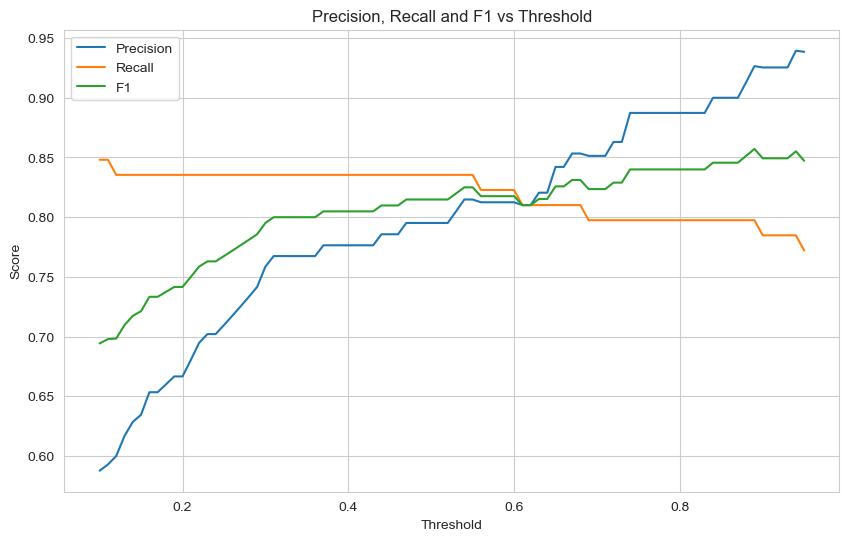

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.show()

In [35]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(), "Threshold"
]

print("Selected threshold:", round(best_threshold, 2))

Selected threshold: 0.89


## 18. Final Model Training



In [36]:
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

X_train_full_smote, y_train_full_smote = SMOTE(
    random_state=RANDOM_STATE
).fit_resample(
    X_train_full_scaled,
    y_train_full
)

final_xgb = XGBClassifier(
    **grid_search.best_params_,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_xgb.fit(X_train_full_smote, y_train_full_smote)

test_prob = final_xgb.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

## 19. Final Test Evaluation

In [37]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob)
}

final_results = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Score"]
)

final_results

,Metric,Score
0,Accuracy,0.999561
1,Precision,0.919540
2,Recall,0.816327
3,F1,0.864865
4,ROC-AUC,0.981079
5,PR-AUC,0.875138


In [38]:
print(classification_report(
    y_test,
    test_pred,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.92      0.82      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



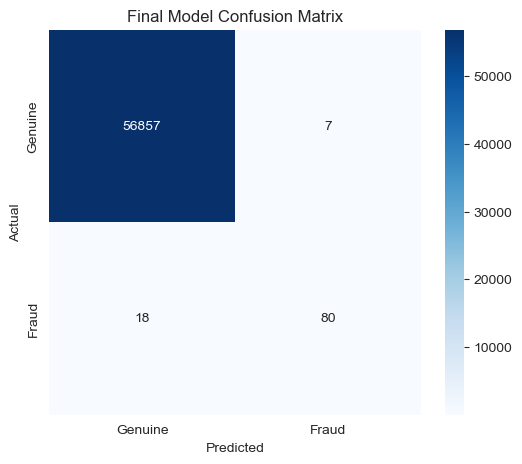

In [39]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")
plt.show()

## 20. ROC Curve

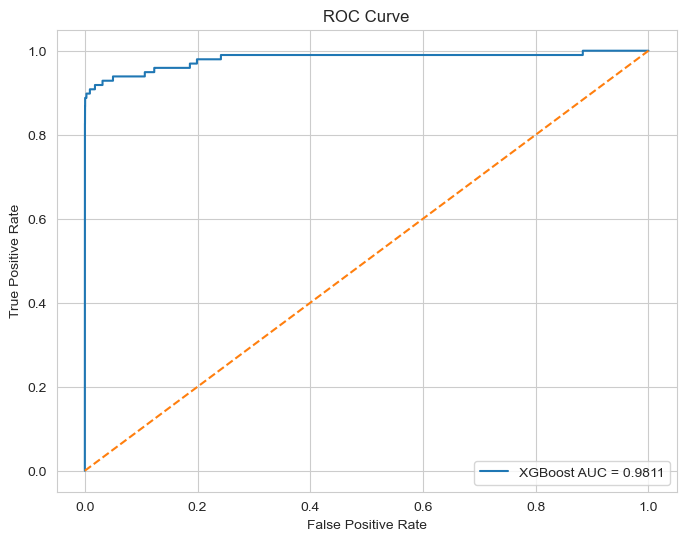

In [40]:
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost AUC = {roc_auc_score(y_test, test_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 21. Precision-Recall Curve

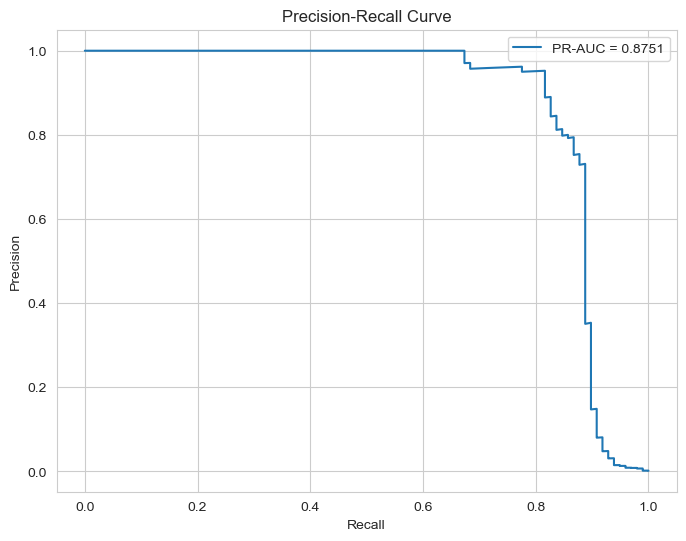

In [41]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {average_precision_score(y_test, test_prob):.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 22. SHAP Explainability



In [43]:
%pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [44]:
import shap

In [45]:
shap_sample_size = min(2000, len(X_test_scaled))
shap_indices = np.random.RandomState(RANDOM_STATE).choice(
    len(X_test_scaled),
    size=shap_sample_size,
    replace=False
)

X_shap = X_test_scaled[shap_indices]
X_shap_df = pd.DataFrame(
    X_shap,
    columns=X_test.columns
)

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_shap_df)

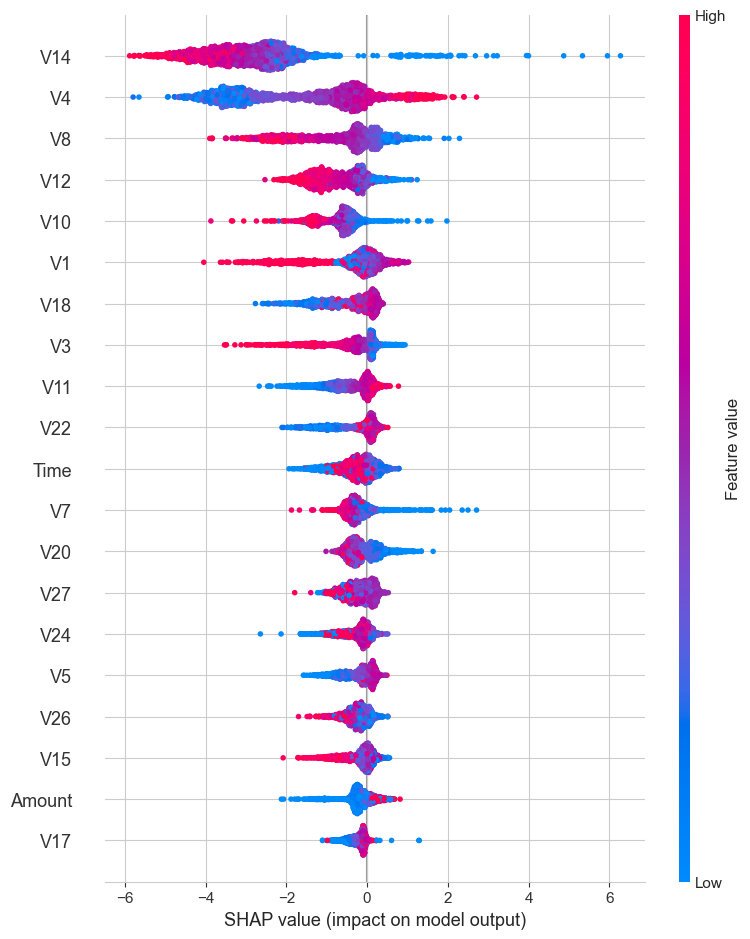

In [46]:
shap.summary_plot(
    shap_values,
    X_shap_df,
    show=True
)

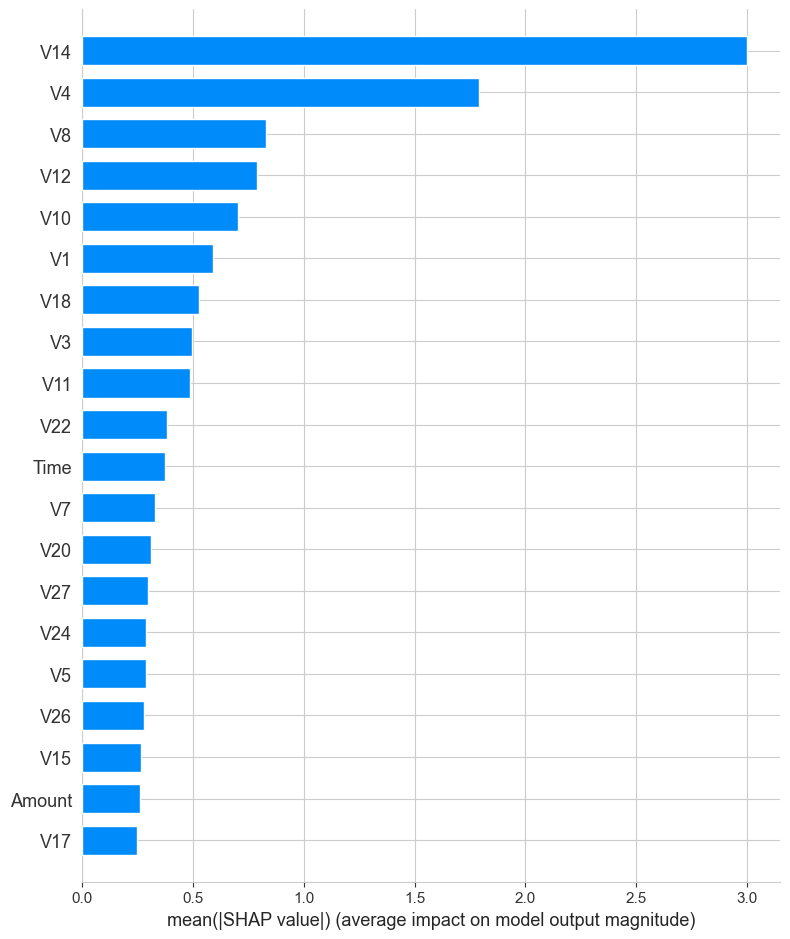

In [47]:
shap.summary_plot(
    shap_values,
    X_shap_df,
    plot_type="bar",
    show=True
)

## 23. Example Fraud Prediction Explanation



Predicted fraud probability: 0.99985445


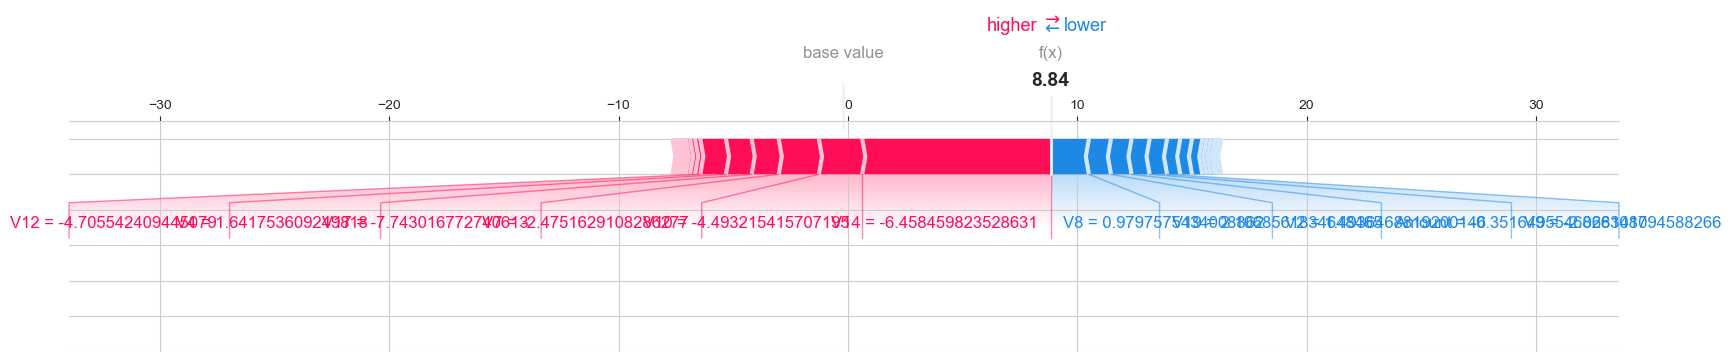

In [48]:
fraud_positions = np.where(test_pred == 1)[0]

if len(fraud_positions) > 0:
    example_position = fraud_positions[0]
    example_transaction = pd.DataFrame(
        X_test.iloc[example_position].values.reshape(1, -1),
        columns=X_test.columns
    )

    example_scaled = scaler.transform(example_transaction)

    example_shap = explainer.shap_values(
        pd.DataFrame(example_scaled, columns=X_test.columns)
    )

    print("Predicted fraud probability:", test_prob[example_position])
    shap.force_plot(
        explainer.expected_value,
        example_shap[0],
        pd.DataFrame(example_scaled, columns=X_test.columns),
        matplotlib=True
    )
else:
    print("No fraud prediction was produced at the selected threshold.")

## 24. Final Model Summary

In [49]:
summary = pd.DataFrame({
    "Component": [
        "Dataset",
        "Samples",
        "Original Fraud Cases",
        "Feature Selection",
        "Imbalance Handling",
        "Model",
        "Cross-Validation",
        "Threshold Selection",
        "Explainability"
    ],
    "Value": [
        "Credit Card Fraud Detection",
        len(df),
        int(y.sum()),
        "Pearson correlation threshold = 0.90",
        "SMOTE",
        "Tuned XGBoost",
        "Stratified 5-Fold",
        f"{best_threshold:.2f}",
        "SHAP"
    ]
})

summary

,Component,Value
0,Dataset,Credit Card Fraud Detection
1,Samples,284807
2,Original Fraud Cases,492
3,Feature Selection,Pearson correlation threshold = 0.90
4,Imbalance Handling,SMOTE
5,Model,Tuned XGBoost
6,Cross-Validation,Stratified 5-Fold
7,Threshold Selection,0.89
8,Explainability,SHAP


## 25. Serializing Production Artifacts for Streamlit Deployment

To transition from research experimentation to an interactive, production-grade **Streamlit** application, we export:
1. **Fitted `StandardScaler`**: Preserves exact feature distribution statistics (`models/scaler.joblib`).
2. **Production Tuned Model (`final_xgb`)**: The optimal XGBoost model trained on SMOTE-balanced data (`models/best_model.joblib`).
3. **Model Metadata & Benchmark Metrics**: Complete test metrics, threshold calibration, and hyperparameter logs (`models/model_metadata.json`).
4. **Threshold Analysis Table**: Precomputed evaluation metrics from threshold `0.01` to `0.99` (`models/threshold_analysis.json`).
5. **Feature Importances**: Global feature importance rankings (`models/feature_importance.json`).
6. **Sample Test Suites**: Real fraud, normal, and mixed batches (`sample_data/`) for 1-click testing in the Streamlit UI.

In [ ]:
import os
import json
import joblib
from pathlib import Path

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('sample_data', exist_ok=True)

# 1. Export Scaler and Best Model
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(final_xgb, 'models/best_model.joblib')
print('✅ Saved Scaler -> models/scaler.joblib')
print('✅ Saved Model  -> models/best_model.joblib')

# 2. Export Feature Importances
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp['Importance'] = feat_imp['Importance'] / feat_imp['Importance'].sum()
feat_imp.to_json('models/feature_importance.json', orient='records', indent=2)
print('✅ Saved Feature Importances -> models/feature_importance.json')

# 3. Export Sample Datasets for Streamlit UI
fraud_cases = df[df['Class'] == 1]
legit_cases = df[df['Class'] == 0]

fraud_cases.sample(n=min(15, len(fraud_cases)), random_state=RANDOM_STATE).to_csv('sample_data/fraud_samples.csv', index=False)
legit_cases.sample(n=min(15, len(legit_cases)), random_state=RANDOM_STATE).to_csv('sample_data/legitimate_samples.csv', index=False)

# Mixed 200-transaction demo batch
batch_demo = pd.concat([
    fraud_cases.sample(n=min(20, len(fraud_cases)), random_state=RANDOM_STATE),
    legit_cases.sample(n=180, random_state=RANDOM_STATE)
]).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
batch_demo.to_csv('sample_data/batch_test_sample.csv', index=False)
print('✅ Saved Sample Datasets -> sample_data/')

# 4. Export Threshold Curve & Metadata
if 'threshold_df' in locals():
    threshold_df.to_json('models/threshold_analysis.json', orient='records', indent=2)
    print('✅ Saved Threshold Analysis -> models/threshold_analysis.json')

metadata = {
    'model_name': 'Tuned XGBoost with SMOTE',
    'optimal_threshold': float(best_threshold) if 'best_threshold' in locals() else 0.89,
    'features': list(X_train.columns),
    'test_samples': len(X_test),
    'test_fraud_cases': int(y_test.sum())
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Saved Metadata -> models/model_metadata.json')


## 26. Financial Risk Modeling & Decision Threshold Optimization

In banking and financial fraud detection, machine learning models are evaluated not only by technical metrics (F1-score, PR-AUC), but by **Total Financial Loss and Customer Friction**.

$$\text{Total Cost} = (\text{FN} \times C_{\text{FN}}) + (\text{FP} \times C_{\text{FP}}) + (\text{TP} \times C_{\text{TP}})$$

- **$C_{\text{FN}}$ (False Negative Cost)**: Direct financial loss due to chargebacks and undetected fraud (default: \$250).
- **$C_{\text{FP}}$ (False Positive Cost)**: Cost of false alarms, customer friction, card re-issuance, and manual audit (default: \$15).
- **$C_{\text{TP}}$ (True Positive Cost)**: Operational handling fee for successfully blocked fraud (default: \$5).

Let us compute the financial loss curve across all decision thresholds to discover the **Cost-Optimal Threshold**.

In [ ]:
def compute_financial_impact(thresholds_df, cost_fn=250.0, cost_fp=15.0, cost_tp=5.0):
    impact = []
    total_fraud = int(thresholds_df.iloc[0]['TP'] + thresholds_df.iloc[0]['FN'])
    baseline_loss = total_fraud * cost_fn

    for _, row in thresholds_df.iterrows():
        total_cost = (row['FN'] * cost_fn) + (row['FP'] * cost_fp) + (row['TP'] * cost_tp)
        net_savings = max(0.0, baseline_loss - total_cost)
        impact.append({
            'Threshold': row['Threshold'],
            'Total_Cost': total_cost,
            'Net_Savings': net_savings,
            'F1': row['F1'],
            'Precision': row['Precision'],
            'Recall': row['Recall']
        })
    return pd.DataFrame(impact), baseline_loss

if 'threshold_df' in locals():
    cost_df, baseline_loss = compute_financial_impact(threshold_df, cost_fn=250.0, cost_fp=15.0)
    min_cost_idx = cost_df['Total_Cost'].idxmin()
    cost_optimal_thresh = cost_df.loc[min_cost_idx, 'Threshold']
    min_cost = cost_df.loc[min_cost_idx, 'Total_Cost']
    max_savings = cost_df.loc[min_cost_idx, 'Net_Savings']

    print(f'💰 Baseline Loss Without ML: ${baseline_loss:,.2f}')
    print(f'🎯 Cost-Optimal Decision Threshold: {cost_optimal_thresh:.2f}')
    print(f'💵 Minimum Incurred Loss: ${min_cost:,.2f}')
    print(f'🚀 Maximum Net Fraud Prevention Savings: ${max_savings:,.2f}')

    # Plot Financial Impact Curve
    plt.figure(figsize=(10, 5))
    plt.plot(cost_df['Threshold'], cost_df['Total_Cost'], label='Total Cost ($)', color='red', lw=2.5)
    plt.plot(cost_df['Threshold'], cost_df['Net_Savings'], label='Net Savings ($)', color='green', lw=2.5)
    plt.axvline(cost_optimal_thresh, color='purple', linestyle='--', label=f'Cost-Optimal: {cost_optimal_thresh:.2f}')
    plt.title('Financial Business Impact vs Decision Threshold', fontsize=14)
    plt.xlabel('Decision Threshold', fontsize=12)
    plt.ylabel('Amount ($ USD)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 27. End-to-End Streamlit Web Application

We have constructed an enterprise-grade interactive **Streamlit Application** (`app.py`) driven by the trained model and serialized artifacts.

### 🌟 Streamlit Application Architecture:
1. **📊 Executive Overview & Data EDA**:
   - Interactive KPIs: Total transactions, fraud prevalence (0.17%), fraud volume ($).
   - Plotly distributions for transaction amounts, 48-hour temporal activity, and correlation heatmaps.
2. **🧠 Model Studio & Benchmark**:
   - Multi-model leaderboard comparing Logistic Regression, Decision Tree, Random Forest, Naive Bayes, and Tuned XGBoost.
   - Interactive in-app model training workbench with live progress tracking.
3. **🎯 Threshold & Cost Optimizer**:
   - Dynamic confusion matrix and PR/ROC curves updated on-the-fly via the threshold slider.
   - Financial loss & ROI calculator to find the exact cost-minimizing threshold for any bank.
4. **🔍 Live Transaction Predictor**:
   - Real-time scoring with 1-click test scenarios (Confirmed Fraud, Everyday Groceries, Luxury Items, Random Sample).
   - Visual Risk Gauge, Risk Tier categorization (Low, Medium, High, Critical), and local feature contribution explanation.
5. **📁 Batch Audit & Scoring**:
   - Upload any CSV batch or test the 200-transaction demo batch.
   - High-throughput batch classification, interactive filtering, and downloadable annotated CSVs.
6. **🧬 Explainability & Intelligence**:
   - Global feature importance (XGBoost Gain) and deep dive into key fraud discriminators (V14, V10, V12, V17).

In [ ]:
# Verify app.py exists and review application files
import os
if os.path.exists('app.py'):
    size_kb = os.path.getsize('app.py') / 1024
    print(f'✅ Streamlit application app.py is ready and available! ({size_kb:.1f} KB)')
else:
    print('⚠️ app.py not found. Please ensure app.py is located in the working directory.')


### 🚀 Launching the Streamlit Application

Execute the cell below to launch the Streamlit server directly from this notebook, or run the following command in your terminal/command prompt:

```bash
streamlit run app.py
```

Once running, open your web browser at **`http://localhost:8501`**.

In [ ]:
# Run Streamlit Web Application directly from notebook
!streamlit run app.py
